In [1]:
import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

In [ ]:
path_scan = "/projects/vig/Datasets/aneurysm/cta_datasets/internal_train/crop_0.4/Tr0001.nii.gz"
path_vessel = "/projects/vig/Datasets/aneurysm/cta_datasets/internal_train/crop_0.4_vessel/Tr0001.nii.gz"
path_vessel_edt = "/scratch/ceballosarroyo.a/aneurysm/cta_datasets/internal_train/crop_0.4_vessel_edt_comp/Tr0001.nii.gz"
scan_header = sitk.ReadImage(path_scan)
scan = sitk.GetArrayFromImage(scan_header)
vessel_header = sitk.ReadImage(path_vessel)
vessel = sitk.GetArrayFromImage(vessel_header)
vessel = (vessel > 0).astype(int)
edt_header = sitk.ReadImage(path_vessel_edt)
edt = sitk.GetArrayFromImage(edt_header)


sz = 64
sz_mask = 8
scan = scan[50 : 50 + sz, 150 : 150 + sz, 200 : 200 + sz]
edt = edt[50 : 50 + sz, 150 : 150 + sz, 200 : 200 + sz]
mask = np.zeros_like(scan)
# randomly turn off  subvolumes of size 2x2x2

for i in range(0, sz, sz_mask):
    for j in range(0, sz, sz_mask):
        for k in range(0, sz, sz_mask):
            if np.random.rand() < 0.75:
                mask[i : i + sz_mask, j : j + sz_mask, k : k + sz_mask] = 1


scan = scan - scan.min()
scan = scan / scan.max()

edt = edt - edt.min()
edt = edt / edt.max()

scan.min(), scan.max()

# apply contrast enhancement

# scan = np.power(scan, lw)
scan = np.power(scan, 0.9)

scan_orig = scan.copy()
edt_orig = edt.copy()
scan = np.ma.masked_where(mask == 1, scan)
edt = np.ma.masked_where(mask == 1, edt)

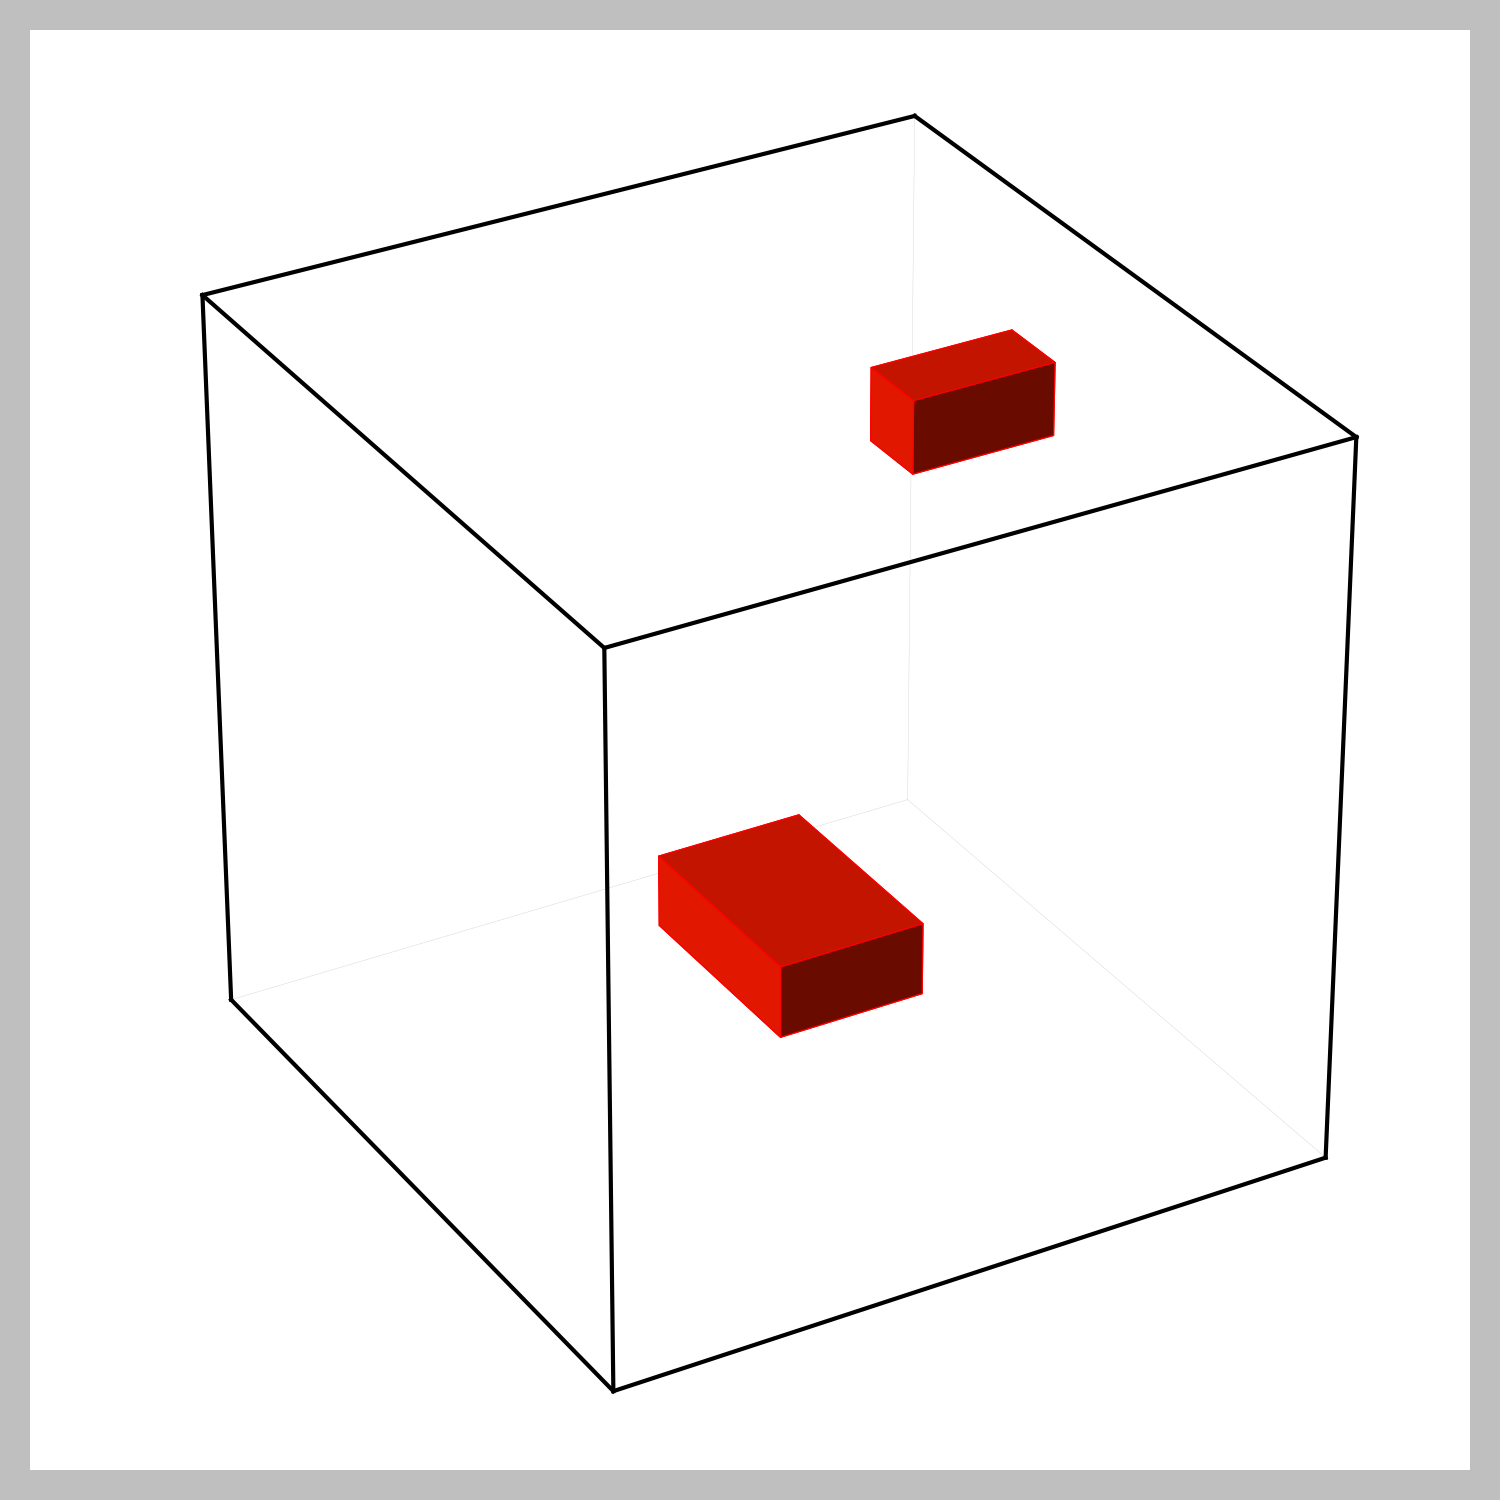

In [146]:
# plot the data as 3d voxels
# apply mask as transparency
plt.style.use('classic')
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values, no edgecolor
#ax.voxels(scan, facecolors=plt.cm.gray(scan), edgecolor="k", alpha=0.9)

# add inferior and superior axes
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_axis_off()
# draw a 3d box inside with full size


# draw a 3d box using 8 lines 
ax.plot([0, 0], [1, 1], [0, 1], color="#d3d3d3", lw=0.1)

ax.plot([0, 0], [0, 1], [0, 0], color="#d3d3d3", lw=0.1)

ax.plot([0, 1], [1, 1], [0, 0       ], color="#d3d3d3", lw=0.1)
ax.plot([0, 1], [0, 0], [0, 0], color="black")
ax.plot([1, 1], [0, 1], [0, 0], color="black")
ax.plot([0, 1], [0, 0], [1, 1], color="black")
ax.plot([0, 1], [1, 1], [1, 1], color="black")
ax.plot([0, 0], [0, 1], [1, 1], color="black")
ax.plot([1, 1], [0, 1], [1, 1], color="black")
ax.plot([0, 0], [0, 0], [0, 1], color="black")
ax.plot([1, 1], [0, 0], [0, 1], color="black")

ax.plot([1, 1], [1, 1], [0, 1], color="black")

# draw red 3d box in the middle
ax.bar3d(
    0.4, 0.4, 0.2, 0.3, 0.2, 0.1,
    color=(1, 0.1, 0, 1),
    edgecolor='red', lw=0.3)


ax.bar3d(
    0.4, 0.7, 0.8, 0.1, 0.2, 0.1,
    color=(1, 0.1, 0, 1),
    edgecolor='red', lw=0.3)

#rotate figure horizontally

ax.view_init(30, -30)

# remove background
ax.set_facecolor("white")
# remove grid
# remove axe# 
ax.grid(False)
ax.set_box_aspect([1,1,1])  # aspect ratio is 1:1:1
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
# draw vertrical line in 3d
ax.axis("off")
ax.get_xaxis().set_ticks([])
ax.get_yaxis().set_ticks([])

plt.savefig("output.png", transparent=True)




plt.show()

In [44]:
128//3

42

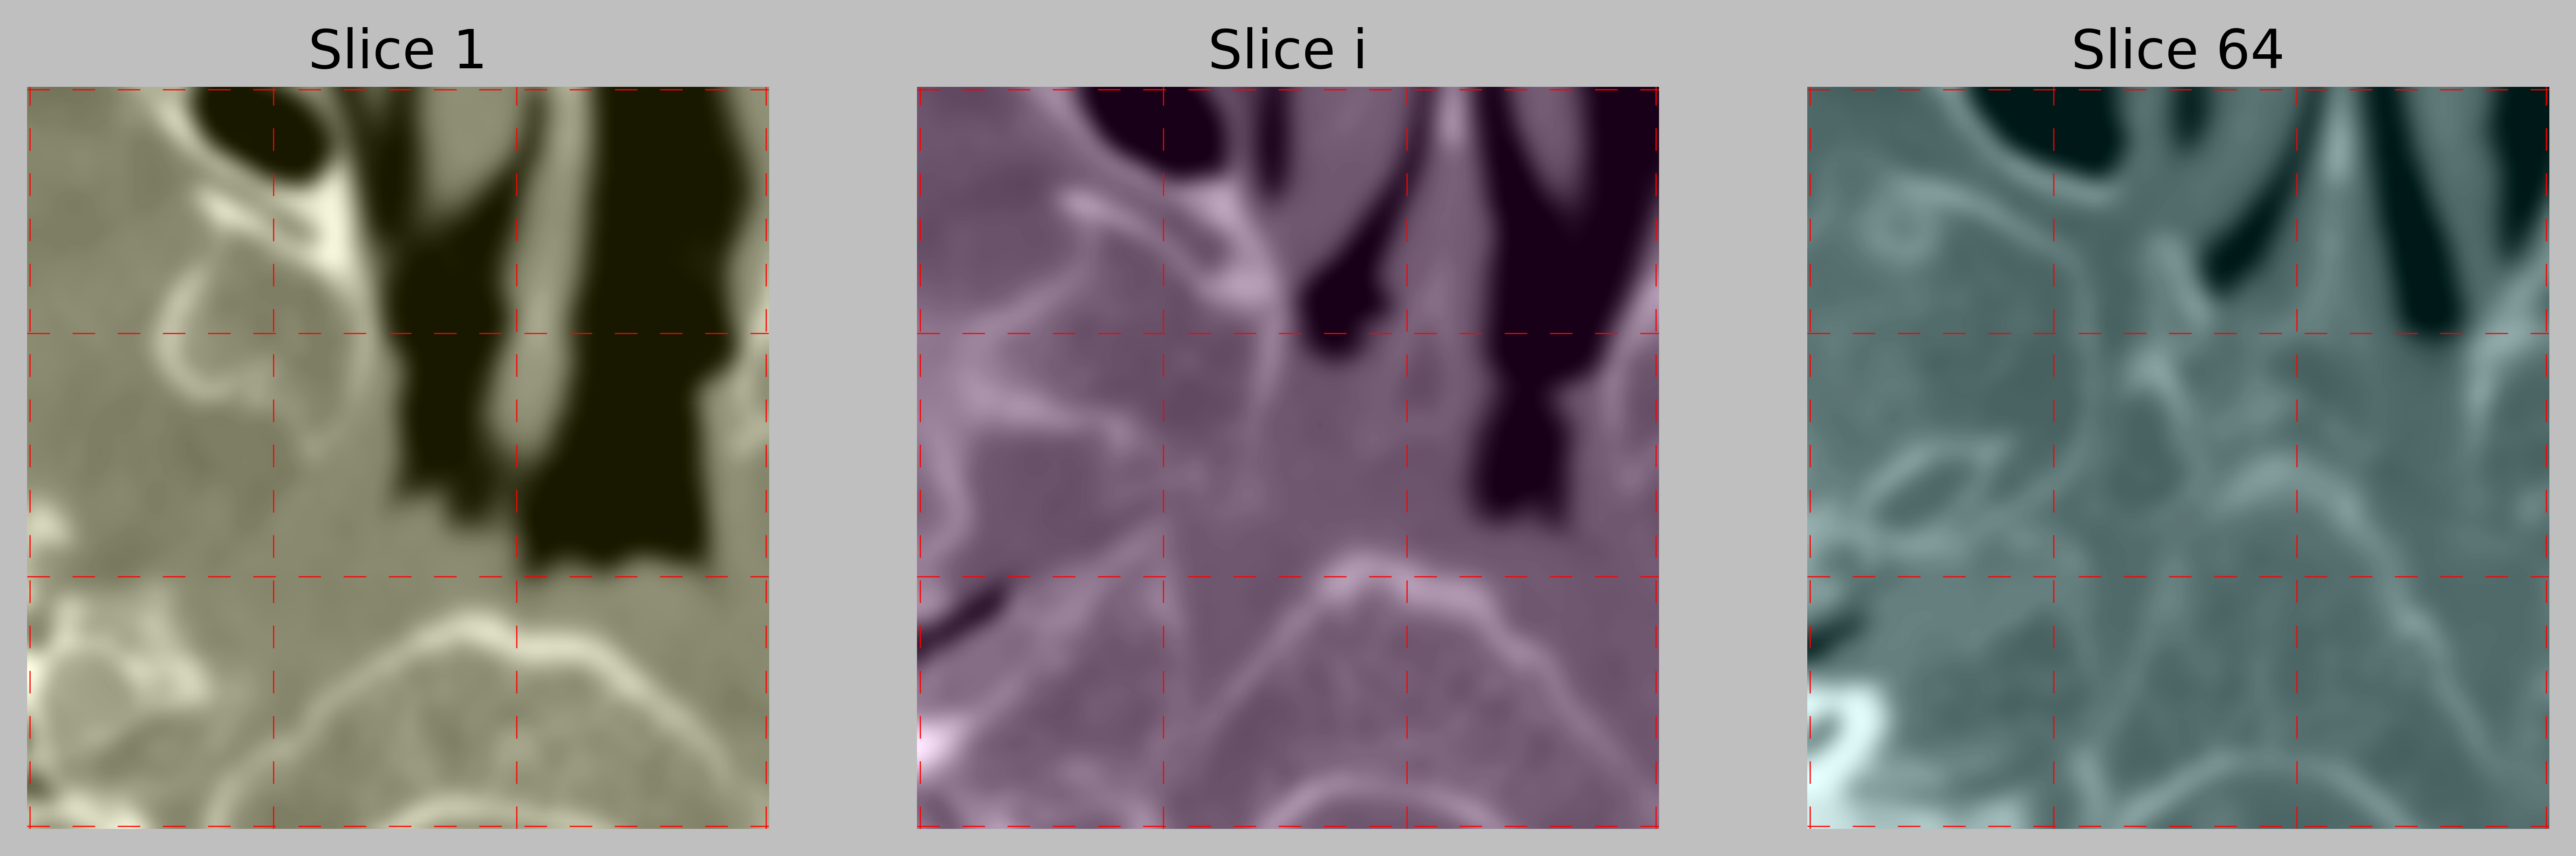

In [59]:
# 1 row, 3 col fig

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=600)
scan = sitk.GetArrayFromImage(scan_header)
sz = 128
scan = scan[75 : 75 + sz, 150 : 150 + sz, 200 : 200 + sz]
scan = scan - scan.min()
scan = scan / scan.max()

# please draw a 4 by 4 grid of lines on top of the scan image 

for i in range(0, sz, sz // 3):
    lw= 0.3
    if i == 126:
        i = 127
    color = "r"
    axs[0].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[0].axvline(i, color=color, linestyle="--", linewidth=lw)
    axs[1].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[1].axvline(i, color=color, linestyle="--", linewidth=lw)
    axs[2].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[2].axvline(i, color=color, linestyle="--", linewidth=lw)

# add transparent yellow color on top of images

yellow_img = np.ones((sz, sz, 3))
yellow_img[:, :, 0] = 1
yellow_img[:, :, 1] = 1
yellow_img[:, :, 2] = 0




im1 = scan[0,:,:]
im2 = scan[6,:,:]
im3 = scan[12,:,:]

axs[0].imshow(im1, cmap="gray")
axs[0].set_title("Slice 1")
axs[0].imshow(yellow_img, alpha=0.1)

axs[0].axis("off")
axs[1].imshow(im2, cmap="gray")
yellow_img[:, :, 0] = 1
yellow_img[:, :, 1] = 0
yellow_img[:, :, 2] = 1
axs[1].imshow(yellow_img, cmap="pink", alpha=0.1)
axs[1].set_title("Slice i")
axs[1].axis("off")

# cyan

yellow_img[:, :, 0] = 0
yellow_img[:, :, 1] = 1
yellow_img[:, :, 2] = 1

axs[2].imshow(im3, cmap="gray")

axs[2].imshow(yellow_img, alpha=0.1)
axs[2].set_title("Slice 64")
axs[2].axis("off")

# save as pdf 

plt.savefig("scan_slices_1.png", bbox_inches="tight", transparent=True)

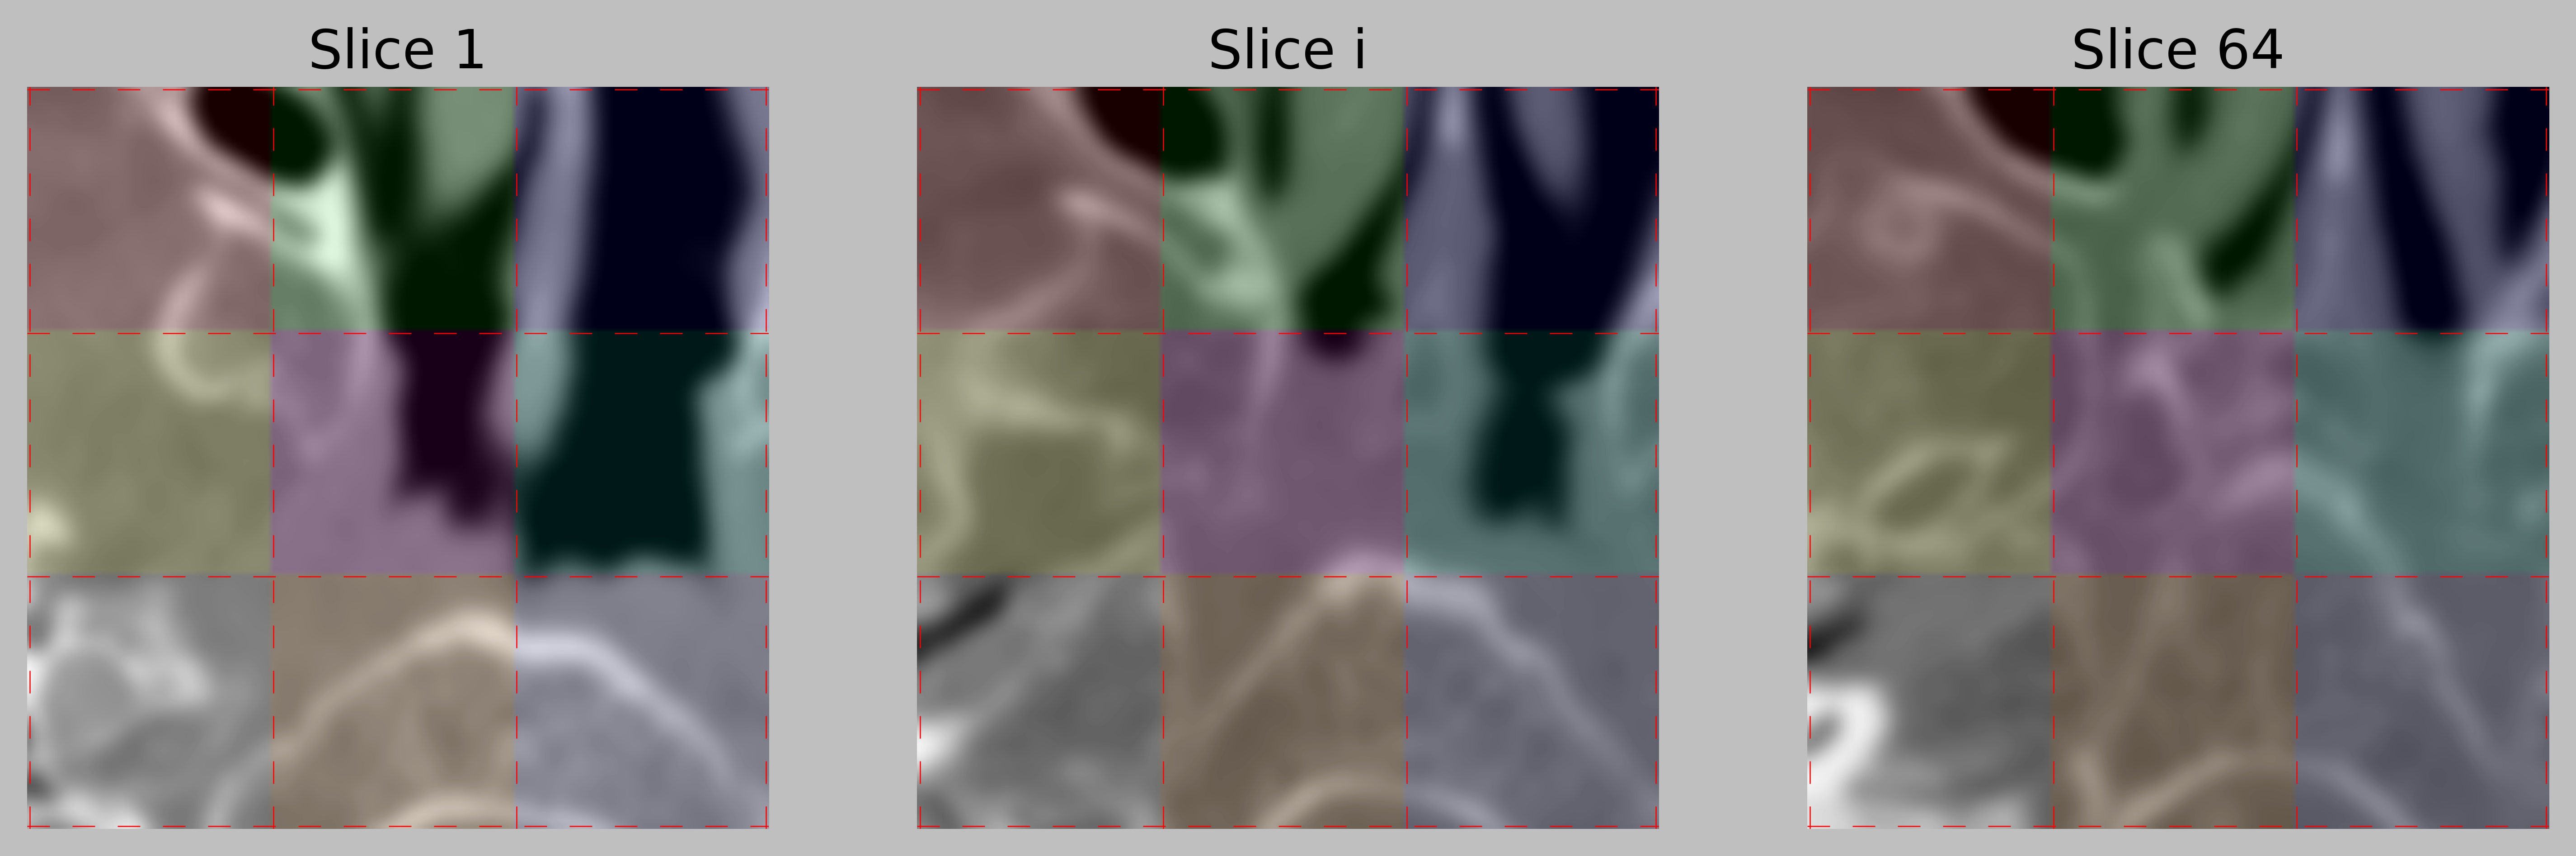

In [60]:
# 1 row, 3 col fig

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=600)
scan = sitk.GetArrayFromImage(scan_header)
sz = 128
scan = scan[75 : 75 + sz, 150 : 150 + sz, 200 : 200 + sz]
scan = scan - scan.min()
scan = scan / scan.max()


# define an array with 9 colors in rgb

colors = [
    [1, 0, 0],  # red
    [0, 1, 0],  # green
    [0, 0, 1],  # blue
    [1, 1, 0],  # yellow
    [1, 0, 1],  # magenta
    [0, 1, 1],  # cyan
    [0.5, 0.5, 0.5],  # gray
    [1, 0.5, 0],  # orange
    [0.5, 0.5, 1],  # purple
]

# draw an empty 2d 128x128 image with 3,3 grids where each grid is a color from above
img = np.zeros((sz, sz, 3))
for i in range(0, 3):
    for j in range(0, 3):
        range_x = slice(i * (sz // 3), (i + 1) * (sz // 3))
        range_y = slice(j * (sz // 3), (j + 1)
                            * (sz // 3))
        if i == 2:
            range_x = slice(i * (sz // 3), sz)
        if j == 2:
            range_y = slice(j * (sz // 3), sz)
        img[range_x, range_y, :] = colors[i * 3 + j]


for i in range(0, sz, sz // 3):
    lw= 0.3
    if i == 126:
        i = 127
    color = "r"
    axs[0].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[0].axvline(i, color=color, linestyle="--", linewidth=lw)
    axs[1].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[1].axvline(i, color=color, linestyle="--", linewidth=lw)
    axs[2].axhline(i, color=color, linestyle="--", linewidth=lw)
    axs[2].axvline(i, color=color, linestyle="--", linewidth=lw)


im1 = scan[0,:,:]
im2 = scan[6,:,:]
im3 = scan[12,:,:]

axs[0].imshow(im1, cmap="gray")
axs[0].set_title("Slice 1")
axs[0].imshow(img, alpha=0.1)

axs[0].axis("off")

axs[1].imshow(im2, cmap="gray")
axs[1].imshow(img, alpha=0.1)
axs[1].set_title("Slice i")
axs[1].axis("off")

axs[2].imshow(im3, cmap="gray")
axs[2].imshow(img, alpha=0.1)
axs[2].set_title("Slice 64")
axs[2].axis("off")

plt.savefig("scan_slices_2.png", bbox_inches="tight", transparent = True)


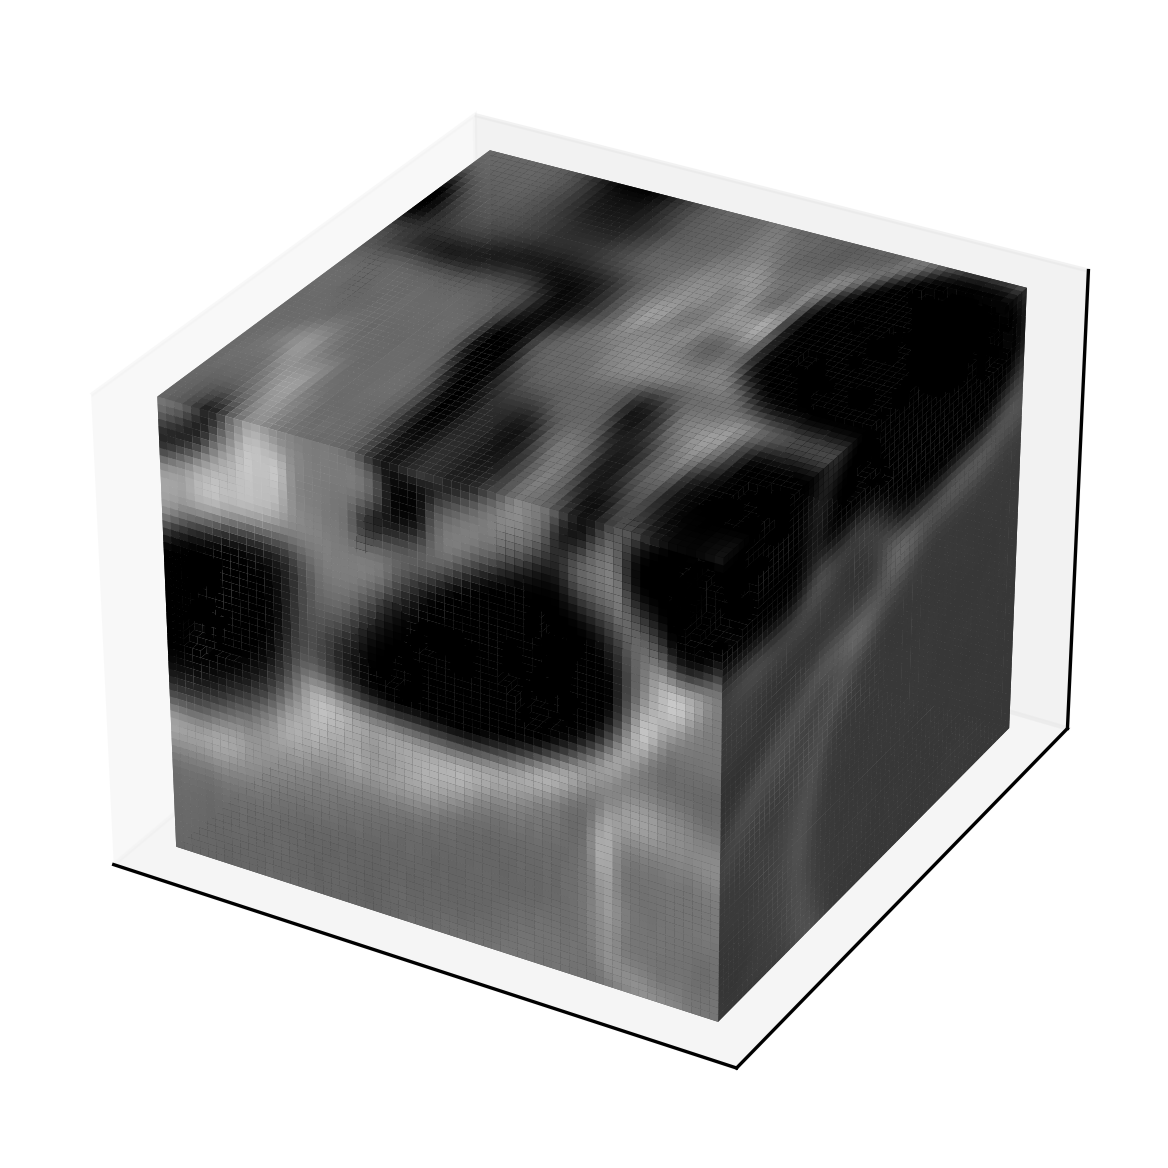

In [124]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
ax.voxels(scan_orig, facecolors=plt.cm.gray(scan_orig))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("scan_full.png")


plt.show()

In [127]:
edt = np.power(edt, 0.9)

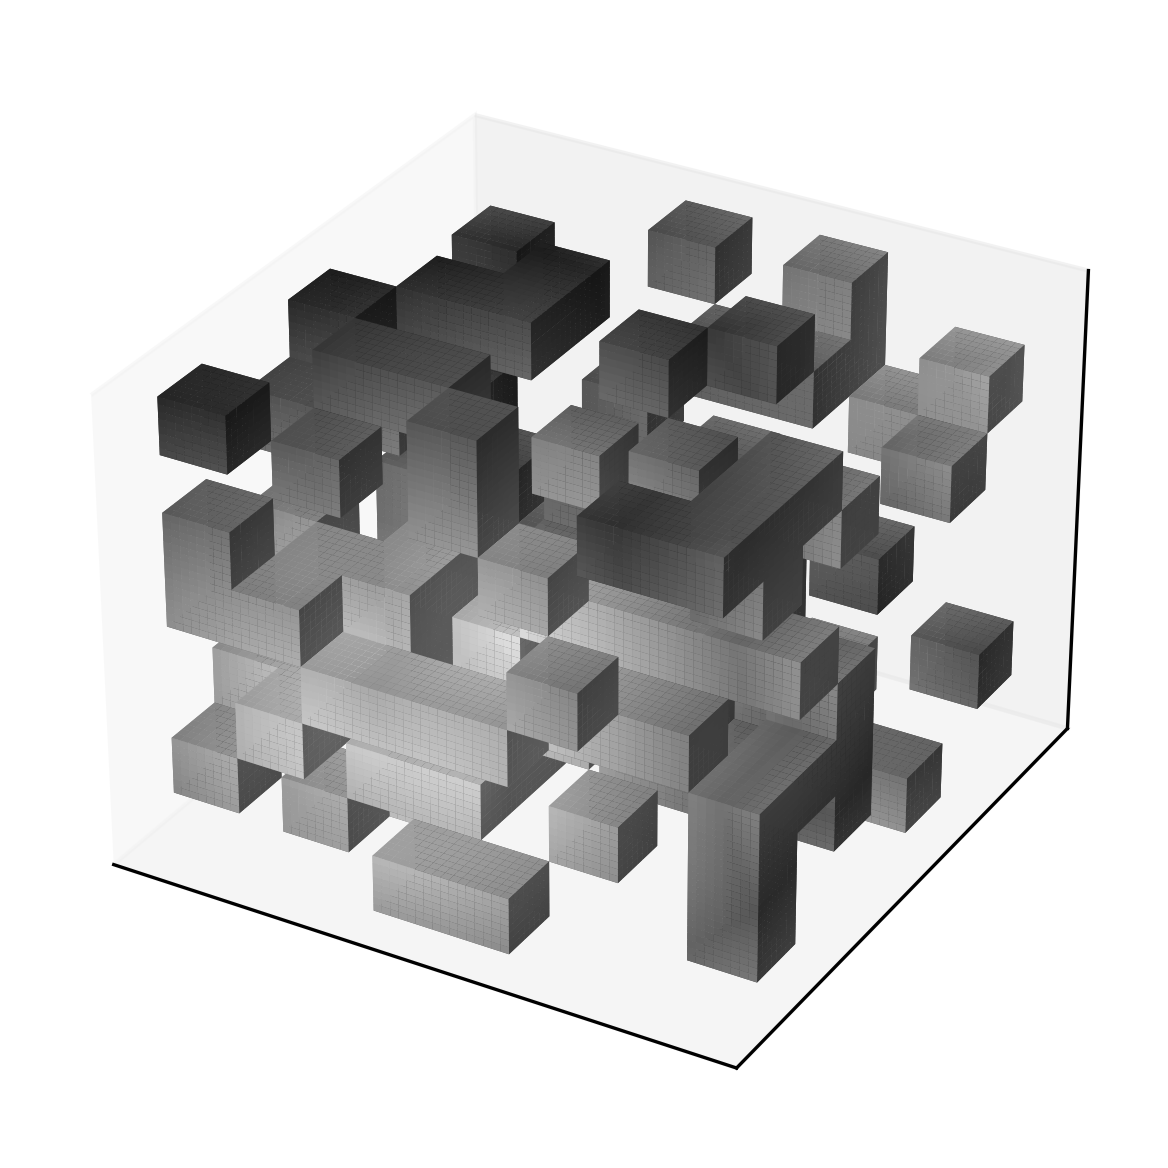

In [128]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
ax.voxels(edt, facecolors=plt.cm.gray(edt))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("edt_masked.png")


plt.show()

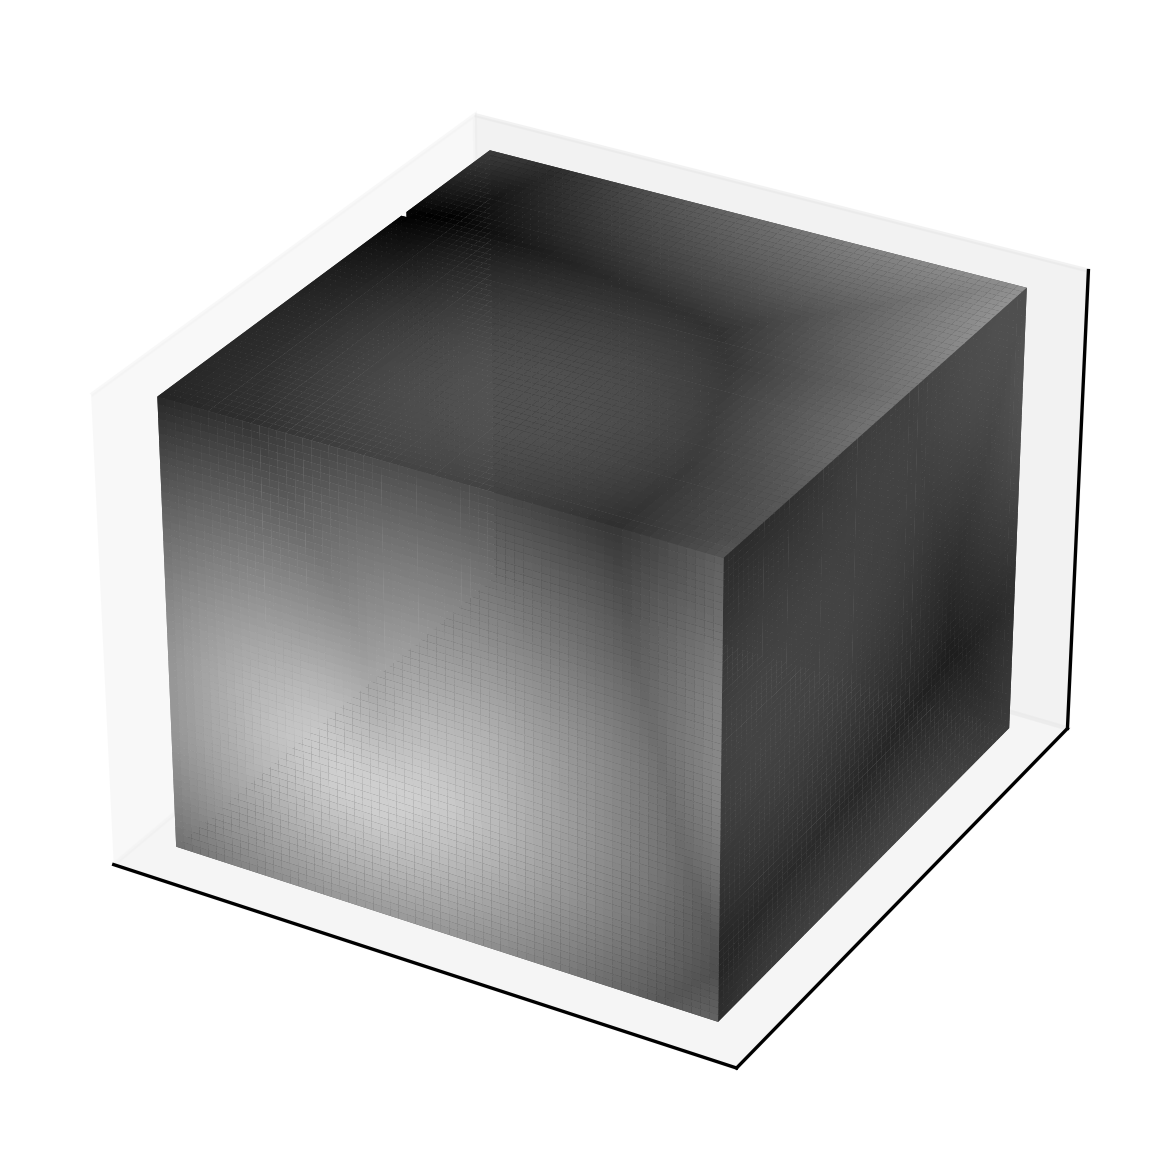

In [129]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
edt_orig = np.power(edt_orig, 0.9)
ax.voxels(edt_orig, facecolors=plt.cm.gray(edt_orig))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("edt_full.png")


plt.show()

0.0 0.8252858958068615


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

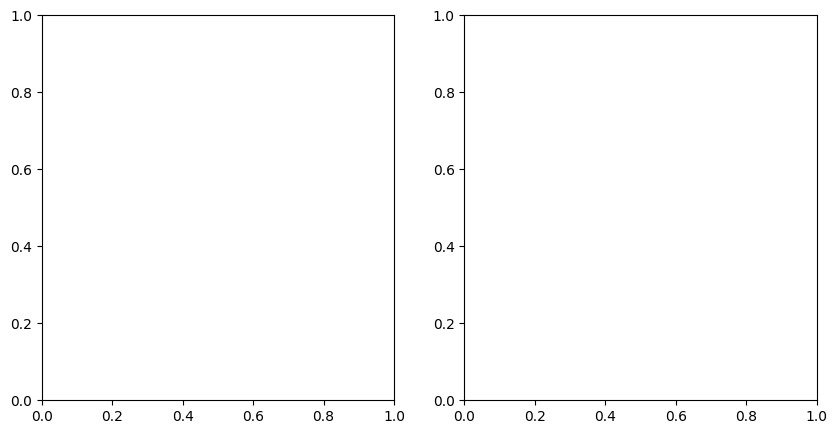

In [83]:
path_scan = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4/Tr0001.nii.gz"
path_vessel = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4_vessel/Tr0001.nii.gz"

scan_header = sitk.ReadImage(path_scan)
scan = sitk.GetArrayFromImage(scan_header)
vessel_header = sitk.ReadImage(path_vessel)
vessel = sitk.GetArrayFromImage(vessel_header)
vessel = (vessel > 0).astype(int)

import random


def plot_slices(scan, vessel, range_x, range_y, slice_num):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    scan = scan[
        slice_num,
        range_x[0] : range_x[1],
        range_y[0] : range_y[1],
    ]
    vessel = vessel[
        slice_num,
        range_x[0] : range_x[1],
        range_y[0] : range_y[1],
    ]

    # overlay a 2d grid on top of the scan with each square being 4x4
    scan = scan / scan.max()
    vessel = vessel / vessel.max()
    scan = np.clip(scan, -1, 1)
    vessel = np.clip(vessel, -1, 1)
    # turn vessel into color image
    vessel_viz = np.zeros((vessel.shape[0], vessel.shape[1], 3))
    # vessel_viz[:, :, 0] = vessel
    vessel_viz[:, :, 1] = vessel
    vessel_viz[:, :, 2] = vessel

    # fill 75% of the scan with 1s following the grid
    #

    for i in range(0, scan.shape[0], 16):
        for j in range(0, scan.shape[1], 16):
            rand = random.random()
            if rand < 0.25 or (
                np.sum(vessel[i : i + 16, j : j + 16]) > 0 and rand < 0.8
            ):
                scan[i : i + 16, j : j + 16] = 1
                # draw an x in the middle of the square
                # for t in range(16):
                #    scan[i + t, j + t] = 0
                #    scan[i + t, j + 15 - t] = 0

                # paint red square in the middle of selected area:
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 0] = 1
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 1] = 0
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 2] = 0

    scan_viz = np.zeros((scan.shape[0], scan.shape[1], 3))
    scan_viz[:, :, 0] = scan
    scan_viz[:, :, 1] = scan
    scan_viz[:, :, 2] = scan

    # overlay vessel as a red transparency ovver the scan
    # save the scan image

    scan_save = (scan_viz - np.min(scan_viz)) / 2
    print(np.min(scan_save), np.max(scan_save))

    scan_save = scan_save * 0.66 + vessel_viz * 0.34
    scan = scan_save
    for i in range(0, scan.shape[0], 16):
        scan[i, :] = 0
    for i in range(0, scan.shape[1], 16):
        scan[:, i] = 0
    scan[:, -1] = 0
    scan[-1, :] = 0

    # resize scan to 512,512

    # import scipy

    # scan = scipy.ndimage.zoom(scan, (1024 / scan.shape[0], 1024 / scan.shape[1], 1))

    plt.imsave("scan.png", scan)
    ax.imshow(scan_viz)
    ax.imshow(vessel_viz, alpha=0.25)

    # ax[0].imshow(scan, cmap="gray")
    # ax[0].set_title("Scan")
    # ax[1].imshow(vessel_viz)
    # ax[1].set_title("Vessel")
    # plt.show()
    # save img
    plt.savefig(f"slice_{slice_num}.png")
    plt.show()


range_x = (150, 214 + 64)
range_y = (200, 264 + 64)

plot_slices(scan, vessel, range_y, range_x, 50)